# Day 01  Mô tả dữ liệu và Table 1

[Open in Colab](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day01.ipynb)

[Slide của buổi này](_static/slides/day01_slides.pptx)

## Mục tiêu bài học

- Đọc đúng cấu trúc của cohort demo
- Xác định biến đích và nhóm biến đầu vào
- Lập Table 1 ngắn gọn cho toàn cohort
- Vẽ ba biểu đồ cơ bản để nhìn nhanh dữ liệu

## Nội dung

Buổi này đi từ dữ liệu thô đến phần mô tả đầu tiên của báo cáo.  
Làm xong buổi này phải trả lời được bốn câu:

- Có bao nhiêu bệnh nhân
- Tỉ lệ EGFR đột biến là bao nhiêu
- Tuổi và kích thước u phân bố ra sao
- Hai nhóm EGFR khác nhau thế nào ở mức mô tả

## Sản phẩm sau bài học

- `table1_overall.csv`
- `table1_by_egfr.csv`
- `hist_age.png`
- `boxplot_tumor_size_by_egfr.png`
- `bar_sex.png`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def read_csv_demo(filename):
    local_candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ]
    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/{filename}"
    return pd.read_csv(url)


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 160
df = read_csv_demo("nsclc_egfr_radiomics_simplified.csv")
output_dir = Path("outputs/day01")
output_dir.mkdir(parents=True, exist_ok=True)


## Bước 1  Đọc dữ liệu và nhìn nhanh số dòng số cột

Cell đầu tiên chỉ để trả lời ba câu ngắn:

- Dữ liệu có bao nhiêu dòng
- Dữ liệu có bao nhiêu cột
- Cột đích là cột nào


In [3]:
df.shape, df.columns.tolist()[:12]


((200, 32),
 ['patient_id',
  'age',
  'sex',
  'smoking_status',
  'histology',
  'stage',
  'tumor_size_mm',
  'tumor_volume_cm3',
  'tp53_mutation',
  'egfr_mutation',
  'intra_firstorder_meanHU',
  'intra_firstorder_medianHU'])

## Bước 2  Xác định nhóm biến

Ở đây chia biến thành ba nhóm:

- Biến lâm sàng
- Biến radiomics của vùng trong u
- Biến radiomics của các vòng quanh u


In [4]:
clinical_cols = ["age", "sex", "smoking_status", "histology", "stage", "tumor_size_mm", "tumor_volume_cm3", "tp53_mutation"]
intra_cols = [c for c in df.columns if c.startswith("intra_")]
ring1_cols = [c for c in df.columns if c.startswith("ring1_")]
ring3_cols = [c for c in df.columns if c.startswith("ring3_")]
ring5_cols = [c for c in df.columns if c.startswith("ring5_")]

pd.DataFrame({
    "Nhom bien": ["Lam sang", "Intra", "Ring1", "Ring3", "Ring5"],
    "So cot": [len(clinical_cols), len(intra_cols), len(ring1_cols), len(ring3_cols), len(ring5_cols)]
})


,Nhom bien,So cot
0,Lam sang,8
1,Intra,7
2,Ring1,5
3,Ring3,5
4,Ring5,5


## Bước 3  Tạo Table 1 cho toàn cohort


In [5]:
table1_overall = pd.DataFrame([
    ["So benh nhan", len(df)],
    ["Tuoi trung binh", round(df["age"].mean(), 1)],
    ["Do lech chuan tuoi", round(df["age"].std(ddof=1), 1)],
    ["Ty le EGFR dot bien", round(df["egfr_mutation"].mean() * 100, 1)],
    ["Kich thuoc u trung vi", round(df["tumor_size_mm"].median(), 1)],
    ["Q1 kich thuoc u", round(df["tumor_size_mm"].quantile(0.25), 1)],
    ["Q3 kich thuoc u", round(df["tumor_size_mm"].quantile(0.75), 1)],
], columns=["Chi so", "Gia tri"])

table1_overall.to_csv(output_dir / "table1_overall.csv", index=False)
table1_overall


,Chi so,Gia tri
0,So benh nhan,200.0
1,Tuoi trung binh,60.4
2,Do lech chuan tuoi,14.0
3,Ty le EGFR dot bien,45.5
4,Kich thuoc u trung vi,35.6
5,Q1 kich thuoc u,28.2
6,Q3 kich thuoc u,41.8


### Cách đọc kết quả

Ở bộ demo này:

- cohort có 200 bệnh nhân
- tỉ lệ EGFR đột biến khoảng 45.5 phần trăm
- tuổi trung bình khoảng 60.4
- kích thước u trung vị khoảng 35.6 mm

Bốn con số này sẽ còn được dùng lại ở Day 05 khi viết phần tóm tắt kết quả.


## Bước 4  So sánh mô tả theo nhóm EGFR


In [6]:
rows = []
for label, sub in df.groupby("egfr_mutation"):
    rows.append({
        "Nhom EGFR": "Dot bien" if label == 1 else "Khong dot bien",
        "n": len(sub),
        "Tuoi trung binh": round(sub["age"].mean(), 1),
        "Do lech chuan tuoi": round(sub["age"].std(ddof=1), 1),
        "Kich thuoc u trung vi": round(sub["tumor_size_mm"].median(), 1),
        "Ti le nu": round((sub["sex"] == "F").mean() * 100, 1),
    })

table1_by_egfr = pd.DataFrame(rows)
table1_by_egfr.to_csv(output_dir / "table1_by_egfr.csv", index=False)
table1_by_egfr


,Nhom EGFR,n,Tuoi trung binh,Do lech chuan tuoi,Kich thuoc u trung vi,Ti le nu
0,Khong dot bien,109,60.4,13.9,35.5,36.7
1,Dot bien,91,60.5,14.2,35.9,58.2


## Bước 5  Vẽ ba biểu đồ cơ bản


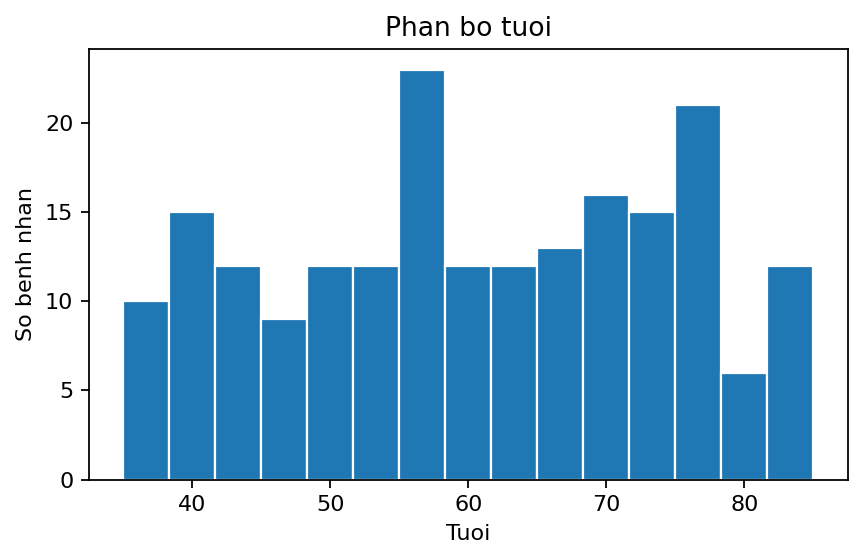

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.hist(df["age"], bins=15, edgecolor="white")
ax.set_title("Phan bo tuoi")
ax.set_xlabel("Tuoi")
ax.set_ylabel("So benh nhan")
fig.tight_layout()
fig.savefig(output_dir / "hist_age.png")
plt.show()


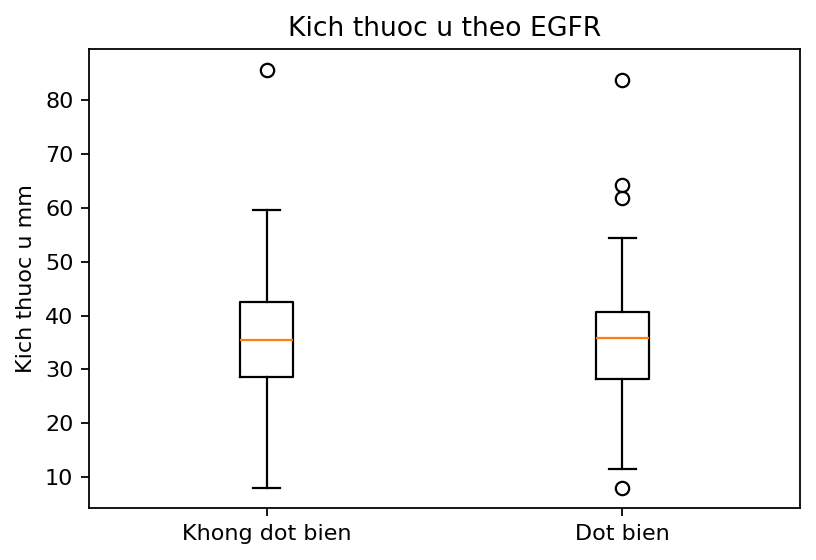

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.boxplot(
    [df.loc[df["egfr_mutation"] == 0, "tumor_size_mm"], df.loc[df["egfr_mutation"] == 1, "tumor_size_mm"]],
    tick_labels=["Khong dot bien", "Dot bien"]
)
ax.set_title("Kich thuoc u theo EGFR")
ax.set_ylabel("Kich thuoc u mm")
fig.tight_layout()
fig.savefig(output_dir / "boxplot_tumor_size_by_egfr.png")
plt.show()


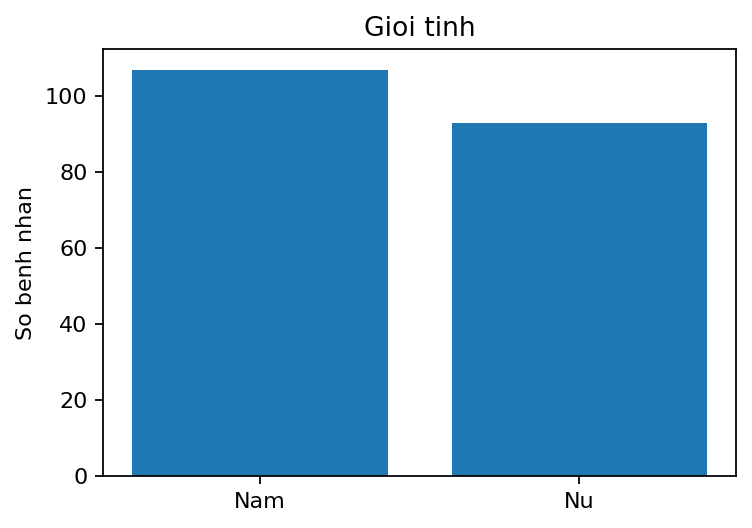

In [9]:
fig, ax = plt.subplots(figsize=(4.8, 3.4))
sex_counts = df["sex"].value_counts().reindex(["M", "F"]).fillna(0)
ax.bar(["Nam", "Nu"], sex_counts.values)
ax.set_title("Gioi tinh")
ax.set_ylabel("So benh nhan")
fig.tight_layout()
fig.savefig(output_dir / "bar_sex.png")
plt.show()


## Bước 6  Ghi ngắn phần mô tả dữ liệu

Đoạn dưới đây là kiểu câu thường dùng trong báo cáo.


In [10]:
summary_day01 = (
    f"Cohort demo co {len(df)} benh nhan. "
    f"Ty le EGFR dot bien la {df['egfr_mutation'].mean() * 100:.1f} phan tram. "
    f"Tuoi trung binh la {df['age'].mean():.1f} va do lech chuan la {df['age'].std(ddof=1):.1f}. "
    f"Kich thuoc u trung vi la {df['tumor_size_mm'].median():.1f} mm."
)
summary_day01


'Cohort demo co 200 benh nhan. Ty le EGFR dot bien la 45.5 phan tram. Tuoi trung binh la 60.4 va do lech chuan la 14.0. Kich thuoc u trung vi la 35.5 mm.'

## Tự kiểm tra

- Có đọc đúng cột đích chưa
- Có phân biệt được biến lâm sàng và biến radiomics chưa
- Có lưu đủ ba hình và hai bảng chưa
- Có viết được bốn câu mô tả cohort chưa
